In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/DS102

Mounted at /content/drive
/content/drive/MyDrive/DS102


In [2]:
!pip -q install scikeras tensorflow

In [5]:
# =========================
# 0) Setup
# =========================
import os
import random
import json
import re
import unicodedata
import pickle
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score, accuracy_score, classification_report

from tensorflow.keras.preprocessing.sequence import pad_sequences


# =========================
# 1) Config + Seed
# =========================
TRAIN_PATH = "./preprocessed-dataset/train_processed.json"
VAL_PATH   = "./preprocessed-dataset/dev_processed.json"
TEST_PATH  = "./preprocessed-dataset/test_processed.json"

# IMPORTANT:
# - PRETRAINED_MODEL_PATH phải là GRU model (có layer tf.keras.layers.GRU)
# - TOKENIZER_PATH phải là tokenizer tương ứng với model (thường pickle)
PRETRAINED_MODEL_PATH = "/content/drive/MyDrive/DS102/sentiment_model_gru.h5"
TOKENIZER_PATH        = "/content/drive/MyDrive/DS102/tokenizer.pkl"  # bạn phải cung cấp file này

SEED = 42

def seed_everything(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

seed_everything(SEED)


# =========================
# 2) Load dữ liệu JSON (không pandas)
# =========================
def load_json_flexible(path: str):
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read().strip()

    if not raw:
        raise ValueError(f"File rỗng: {path}")

    if raw.lstrip().startswith("["):
        data = json.loads(raw)
        if not isinstance(data, list):
            raise ValueError(f"JSON array không hợp lệ (không phải list): {path}")
        return data

    items = []
    for i, line in enumerate(raw.splitlines(), start=1):
        line = line.strip()
        if not line:
            continue
        try:
            items.append(json.loads(line))
        except json.JSONDecodeError as err:
            raise ValueError(f"Lỗi JSON Lines tại dòng {i} trong {path}: {err}") from err
    return items


def validate_and_extract(records, split_name: str):
    reviews, sentiments = [], []
    for idx, r in enumerate(records):
        if not isinstance(r, dict):
            raise ValueError(f"{split_name}: phần tử {idx} không phải object JSON")
        if "review" not in r or "sentiment" not in r:
            raise ValueError(f"{split_name}: phần tử {idx} thiếu 'review' hoặc 'sentiment'")
        reviews.append(r["review"])
        sentiments.append(r["sentiment"])
    return reviews, sentiments


train_records = load_json_flexible(TRAIN_PATH)
val_records   = load_json_flexible(VAL_PATH)
test_records  = load_json_flexible(TEST_PATH)

X_train_raw, y_train_raw = validate_and_extract(train_records, "train")
X_val_raw,   y_val_raw   = validate_and_extract(val_records, "val")
X_test_raw,  y_test_raw  = validate_and_extract(test_records, "test")


# =========================
# 3) Preprocess text (giống bạn: clean + bỏ dấu)
# =========================
def clean_review_basic(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    text = text.replace("_", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def remove_vietnamese_accents(text):
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize("NFD", text)
    text = "".join(ch for ch in text if unicodedata.category(ch) != "Mn")
    text = unicodedata.normalize("NFC", text)
    return text

def preprocess_review(text):
    return remove_vietnamese_accents(clean_review_basic(text))

X_train = [preprocess_review(t) for t in X_train_raw]
X_val   = [preprocess_review(t) for t in X_val_raw]
X_test  = [preprocess_review(t) for t in X_test_raw]

def normalize_label(x):
    return str(x).lower().strip()

y_train_norm = [normalize_label(x) for x in y_train_raw]
y_val_norm   = [normalize_label(x) for x in y_val_raw]
y_test_norm  = [normalize_label(x) for x in y_test_raw]

# Encode label
le = LabelEncoder()
le.fit(y_train_norm)

val_extra  = set(y_val_norm)  - set(le.classes_)
test_extra = set(y_test_norm) - set(le.classes_)
if val_extra or test_extra:
    raise ValueError(
        "Val/Test có nhãn không xuất hiện trong Train.\n"
        f"Val extra labels: {sorted(val_extra)}\n"
        f"Test extra labels: {sorted(test_extra)}\n"
        f"Train labels: {list(le.classes_)}"
    )

y_train = le.transform(y_train_norm)
y_val   = le.transform(y_val_norm)
y_test  = le.transform(y_test_norm)

num_classes = len(le.classes_)
print("Classes:", list(le.classes_))


# =========================
# 4) Load tokenizer + vectorize sequences
# =========================
if not os.path.exists(TOKENIZER_PATH):
    raise ValueError(
        f"Thiếu TOKENIZER_PATH: {TOKENIZER_PATH}\n"
        "Bạn phải có tokenizer/vocab đúng của pretrained model để biến text -> token IDs."
    )

with open(TOKENIZER_PATH, "rb") as f:
    tokenizer = pickle.load(f)

# Load pretrained model và kiểm tra GRU
def load_pretrained_gru_or_fail(model_path: str) -> tf.keras.Model:
    if not os.path.exists(model_path):
        raise ValueError(f"Không tìm thấy pretrained model: {model_path}")

    m = tf.keras.models.load_model(model_path, compile=False)

    has_gru = any(isinstance(layer, tf.keras.layers.GRU) for layer in m.layers)
    if not has_gru:
        layer_types = [layer.__class__.__name__ for layer in m.layers]
        raise ValueError(
            "Pretrained model KHÔNG có layer GRU (yêu cầu của bạn là chỉ GRU pretrained).\n"
            f"Layer types: {layer_types}"
        )
    return m

pretrained = load_pretrained_gru_or_fail(PRETRAINED_MODEL_PATH)

# Infer seq_len từ input_shape
seq_len = pretrained.input_shape[1]
if seq_len is None:
    raise ValueError("Không suy ra được seq_len từ pretrained.input_shape. Cần model có input_length cố định.")

def texts_to_padded_ids(texts, max_len: int):
    seqs = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(seqs, maxlen=max_len, padding="post", truncating="post")
    return padded.astype(np.int32)

X_train_seq = texts_to_padded_ids(X_train, seq_len)
X_val_seq   = texts_to_padded_ids(X_val, seq_len)
X_test_seq  = texts_to_padded_ids(X_test, seq_len)


# =========================
# 5) TF-IDF features
# =========================
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train).toarray().astype(np.float32)
X_val_tfidf   = tfidf.transform(X_val).toarray().astype(np.float32)
X_test_tfidf  = tfidf.transform(X_test).toarray().astype(np.float32)

tfidf_dim = X_train_tfidf.shape[1]
print("TF-IDF dim:", tfidf_dim)


# =========================
# 6) Build combined model: GRU(pretrained encoder) + TF-IDF
# =========================
def build_combined_model(
    pretrained_model_path: str,
    seq_len: int,
    tfidf_dim: int,
    num_classes: int,
    head_units: int = 64,
    tfidf_units: int = 128,
    dropout: float = 0.3,
    lr: float = 1e-3,
    freeze_pretrained: bool = True,
):
    seed_everything(SEED)
    tf.keras.backend.clear_session()

    base = tf.keras.models.load_model(pretrained_model_path, compile=False)

    # enforce GRU existence
    if not any(isinstance(layer, tf.keras.layers.GRU) for layer in base.layers):
        layer_types = [layer.__class__.__name__ for layer in base.layers]
        raise ValueError(f"Model không có GRU. Layer types: {layer_types}")

    # IMPORTANT: build/call once so base.input and layer outputs exist (Keras 3 Sequential quirk)
    dummy = tf.zeros((1, seq_len), dtype=tf.int32)
    _ = base(dummy)

    # pick encoder layer output (avoid final classifier Dense + avoid Dropout right before it)
    encoder_layer_idx = -2
    while abs(encoder_layer_idx) <= len(base.layers) and isinstance(base.layers[encoder_layer_idx], tf.keras.layers.Dropout):
        encoder_layer_idx -= 1

    encoder_out = base.layers[encoder_layer_idx].output
    encoder = tf.keras.Model(inputs=base.inputs, outputs=encoder_out, name="pretrained_encoder")
    encoder.trainable = not freeze_pretrained

    seq_in = tf.keras.Input(shape=(seq_len,), dtype=tf.int32, name="seq")
    tfidf_in = tf.keras.Input(shape=(tfidf_dim,), dtype=tf.float32, name="tfidf")

    x_seq = encoder(seq_in)
    if len(x_seq.shape) == 3:
        x_seq = tf.keras.layers.GlobalMaxPooling1D()(x_seq)

    x_tfidf = tf.keras.layers.Dense(tfidf_units, activation="relu")(tfidf_in)
    x_tfidf = tf.keras.layers.Dropout(dropout)(x_tfidf)

    x = tf.keras.layers.Concatenate()([x_seq, x_tfidf])
    x = tf.keras.layers.Dense(head_units, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs={"seq": seq_in, "tfidf": tfidf_in}, outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return model

# =========================
# 7) Manual Grid Search trên tập Val
# =========================
param_grid = {
    "head_units": [64, 128, 256],
    "tfidf_units": [128, 256, 512],
    "dropout": [0.6],
    "lr": [1e-3],
    "freeze_pretrained": [True, False],
}

best = {
    "params": None,
    "val_f1": -1.0,
    "val_acc": -1.0,
}

for params in ParameterGrid(param_grid):
    print("Trying:", params)

    model = build_combined_model(
        pretrained_model_path=PRETRAINED_MODEL_PATH,
        seq_len=seq_len,
        tfidf_dim=tfidf_dim,
        num_classes=num_classes,
        **params,
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    )

    model.fit(
        {"seq": X_train_seq, "tfidf": X_train_tfidf},
        y_train,
        validation_data=({"seq": X_val_seq, "tfidf": X_val_tfidf}, y_val),
        epochs=10,
        batch_size=32,
        callbacks=[es],
        verbose=0,
    )

    val_prob = model.predict({"seq": X_val_seq, "tfidf": X_val_tfidf}, verbose=0)
    val_pred = np.argmax(val_prob, axis=1)

    val_f1 = f1_score(y_val, val_pred, average="macro")
    val_acc = accuracy_score(y_val, val_pred)

    print(f"  val_f1_macro={val_f1:.4f}  val_acc={val_acc:.4f}")

    if val_f1 > best["val_f1"]:
        best.update({"params": params, "val_f1": val_f1, "val_acc": val_acc})

print("\nBest params:", best["params"])
print(f"Best val_f1_macro={best['val_f1']:.4f}  val_acc={best['val_acc']:.4f}")


# =========================
# 8) Train lại với best params và evaluate Test
# =========================
best_model = build_combined_model(
    pretrained_model_path=PRETRAINED_MODEL_PATH,
    seq_len=seq_len,
    tfidf_dim=tfidf_dim,
    num_classes=num_classes,
    **best["params"],
)

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

best_model.fit(
    {"seq": X_train_seq, "tfidf": X_train_tfidf},
    y_train,
    validation_data=({"seq": X_val_seq, "tfidf": X_val_tfidf}, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[es],
    verbose=1,
)

Classes: [np.str_('negative'), np.str_('neutral'), np.str_('positive')]
TF-IDF dim: 2424
Trying: {'dropout': 0.6, 'freeze_pretrained': True, 'head_units': 64, 'lr': 0.001, 'tfidf_units': 128}
  val_f1_macro=0.6315  val_acc=0.6311
Trying: {'dropout': 0.6, 'freeze_pretrained': True, 'head_units': 64, 'lr': 0.001, 'tfidf_units': 256}
  val_f1_macro=0.6181  val_acc=0.6230
Trying: {'dropout': 0.6, 'freeze_pretrained': True, 'head_units': 64, 'lr': 0.001, 'tfidf_units': 512}
  val_f1_macro=0.6273  val_acc=0.6311
Trying: {'dropout': 0.6, 'freeze_pretrained': True, 'head_units': 128, 'lr': 0.001, 'tfidf_units': 128}
  val_f1_macro=0.6525  val_acc=0.6516
Trying: {'dropout': 0.6, 'freeze_pretrained': True, 'head_units': 128, 'lr': 0.001, 'tfidf_units': 256}
  val_f1_macro=0.6379  val_acc=0.6434
Trying: {'dropout': 0.6, 'freeze_pretrained': True, 'head_units': 128, 'lr': 0.001, 'tfidf_units': 512}
  val_f1_macro=0.6120  val_acc=0.6189
Trying: {'dropout': 0.6, 'freeze_pretrained': True, 'head_unit


===== DEV (VAL) =====
Accuracy: 0.6721311475409836
F1-macro : 0.6694435109688298

Classification report:
              precision    recall  f1-score   support

    negative     0.6522    0.7895    0.7143        76
     neutral     0.6436    0.6771    0.6599        96
    positive     0.7647    0.5417    0.6341        72

    accuracy                         0.6721       244
   macro avg     0.6868    0.6694    0.6694       244
weighted avg     0.6820    0.6721    0.6692       244


===== TEST =====
Accuracy: 0.7081632653061225
F1-macro : 0.7087947921940226

Classification report:
              precision    recall  f1-score   support

    negative     0.7628    0.7881    0.7752       151
     neutral     0.6927    0.6856    0.6891       194
    positive     0.6690    0.6552    0.6620       145

    accuracy                         0.7082       490
   macro avg     0.7082    0.7096    0.7088       490
weighted avg     0.7073    0.7082    0.7076       490



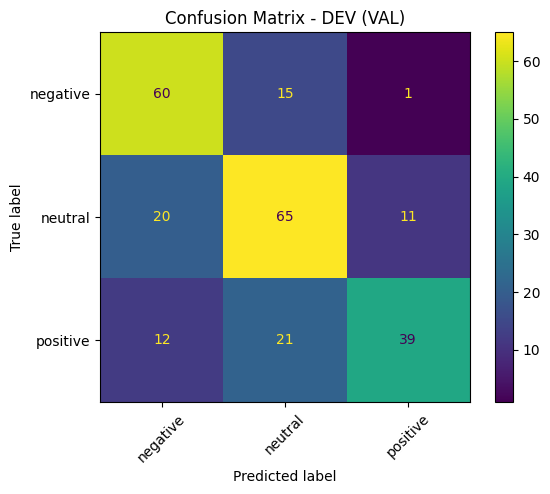

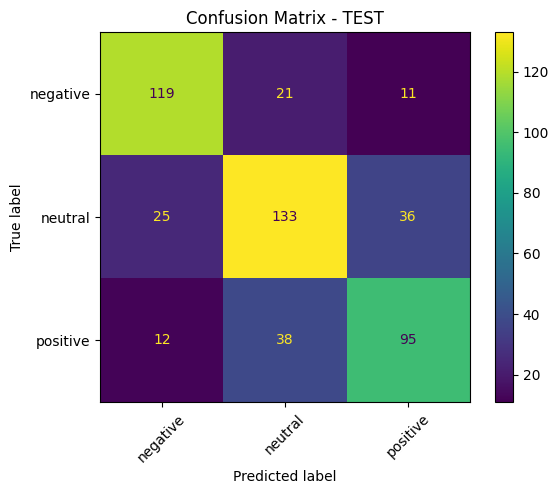

In [6]:
# =========================
# Evaluate Dev (Val) + Test
# =========================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def eval_split(model, X_seq, X_tfidf, y_true, split_name: str):
    prob = model.predict({"seq": X_seq, "tfidf": X_tfidf}, verbose=0)
    y_pred = np.argmax(prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")

    print(f"\n===== {split_name} =====")
    print("Accuracy:", acc)
    print("F1-macro :", f1m)
    print("\nClassification report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=[str(x) for x in le.classes_],
        digits=4
    ))
    return y_pred

# Dev / Val
val_pred = eval_split(best_model, X_val_seq, X_val_tfidf, y_val, "DEV (VAL)")

# Test
test_pred = eval_split(best_model, X_test_seq, X_test_tfidf, y_test, "TEST")

# (Optional) Confusion matrices
cm_val = confusion_matrix(y_val, val_pred)
disp_val = ConfusionMatrixDisplay(cm_val, display_labels=[str(x) for x in le.classes_])
disp_val.plot(xticks_rotation=45)
plt.title("Confusion Matrix - DEV (VAL)")
plt.show()

cm_test = confusion_matrix(y_test, test_pred)
disp_test = ConfusionMatrixDisplay(cm_test, display_labels=[str(x) for x in le.classes_])
disp_test.plot(xticks_rotation=45)
plt.title("Confusion Matrix - TEST")
plt.show()